In [1]:
from google.colab import files
uploaded = files.upload()


Saving home_bakery_orders.xlsx to home_bakery_orders.xlsx


In [2]:
import pandas as pd
df = pd.read_excel("home_bakery_orders.xlsx")
df.head()

,Order_ID,Date,Item_Name,Category,Quantity,Price_per_unit,Total_Amount,Payment_Mode,Customer_Name
0,ORD001,2024-05-28,Oatmeal Cookie,Cookie,1,90,90,Paytm,Christopher
1,ORD002,2024-05-23,Oatmeal Cookie,Cookie,5,90,450,PhonePe,Sarah
2,ORD003,2024-05-15,Vanilla Cupcake,Cupcake,4,80,320,PhonePe,Benjamin
3,ORD004,2024-05-31,Oatmeal Cookie,Cookie,3,90,270,PhonePe,Karen
4,ORD005,2024-05-08,Blueberry Muffin,Muffin,2,100,200,GPay,Joshua


In [4]:
df.describe()
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Order_ID        60 non-null     object
 1   Date            60 non-null     object
 2   Item_Name       60 non-null     object
 3   Category        60 non-null     object
 4   Quantity        60 non-null     int64 
 5   Price_per_unit  60 non-null     int64 
 6   Total_Amount    60 non-null     int64 
 7   Payment_Mode    60 non-null     object
 8   Customer_Name   60 non-null     object
dtypes: int64(3), object(6)
memory usage: 4.3+ KB


Index(['Order_ID', 'Date', 'Item_Name', 'Category', 'Quantity',
       'Price_per_unit', 'Total_Amount', 'Payment_Mode', 'Customer_Name'],
      dtype='object')

In [5]:
df.isnull().sum()

,0
Order_ID,0
Date,0
Item_Name,0
Category,0
Quantity,0
Price_per_unit,0
Total_Amount,0
Payment_Mode,0
Customer_Name,0


In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df['Month'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day_name()

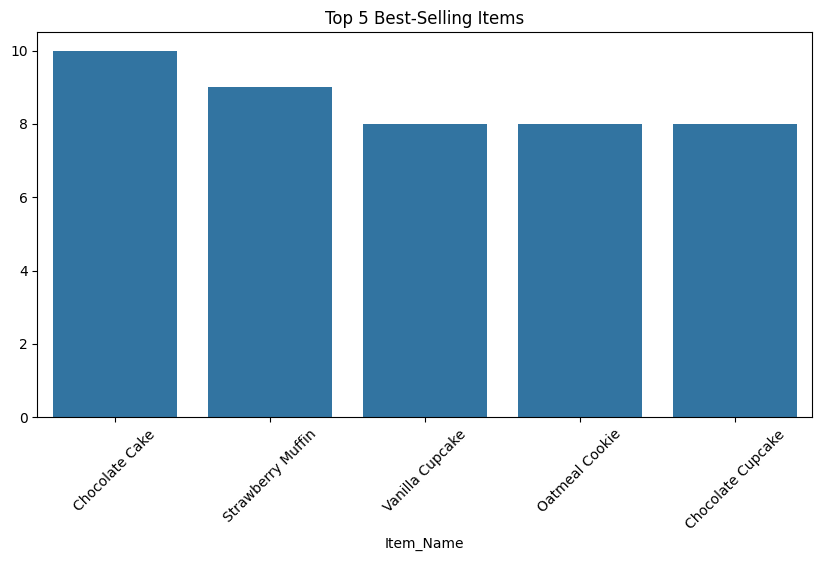

In [9]:
#top 5 selling
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(x=df['Item_Name'].value_counts().index[:5],
            y=df['Item_Name'].value_counts().values[:5])
plt.title("Top 5 Best-Selling Items")
plt.xticks(rotation=45)
plt.show()

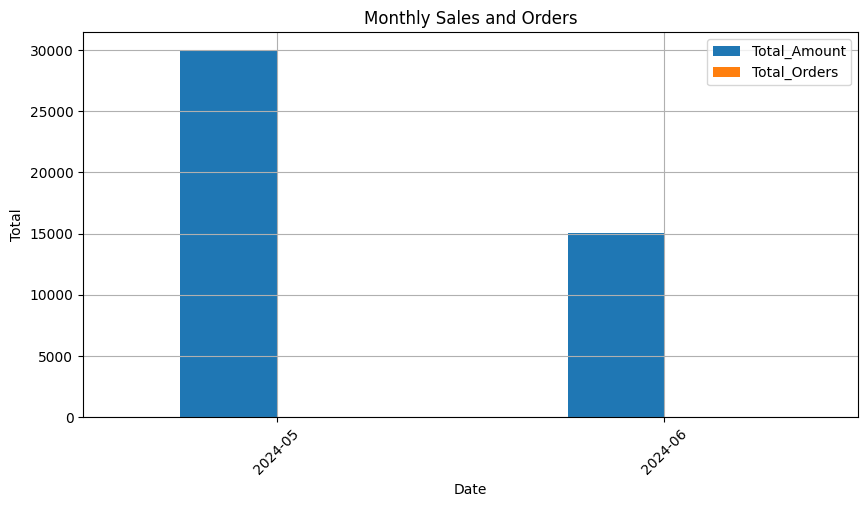

In [11]:
#Monthly Sales Analysis
monthly_sales = df.groupby(df['Date'].dt.to_period('M')).agg({
    "Total_Amount": "sum",
    "Order_ID": "count"
}).rename(columns={"Order_ID": "Total_Orders"})


monthly_sales.plot(kind="bar", figsize=(10,5))
plt.title("Monthly Sales and Orders")
plt.ylabel("Total")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

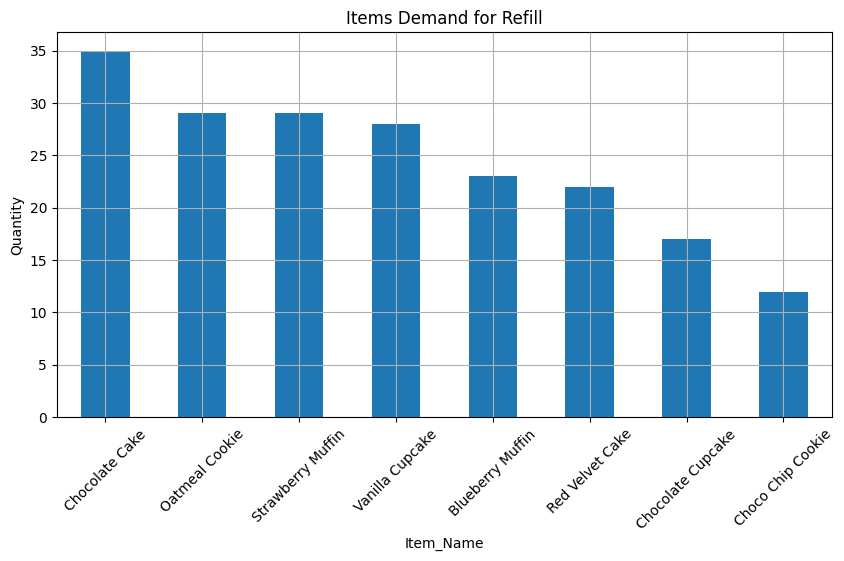

In [17]:
# Inventory Refill Strategy (Item demands)
item_demand = df.groupby("Item_Name")["Quantity"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
item_demand.plot(kind='bar')
plt.title("Items Demand for Refill")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

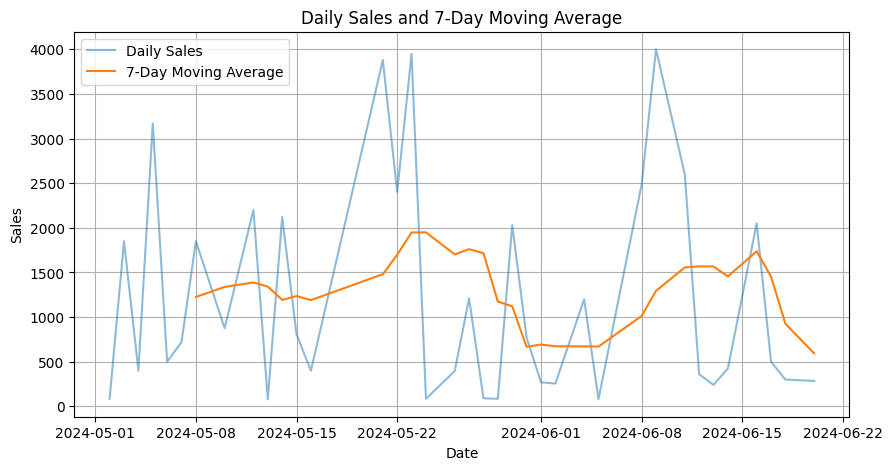

In [18]:
#Sales Forecasting
df_daily = df.groupby('Date')['Total_Amount'].sum().reset_index()

# 7-day moving average
df_daily['7DMA']= df_daily['Total_Amount'].rolling(window=7).mean()
plt.figure(figsize=(10,5))
plt.plot(df_daily['Date'], df_daily['Total_Amount'], label="Daily Sales" , alpha = 0.5)
plt.plot(df_daily['Date'],df_daily['7DMA'],label="7-Day Moving Average")
plt.title("Daily Sales and 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()


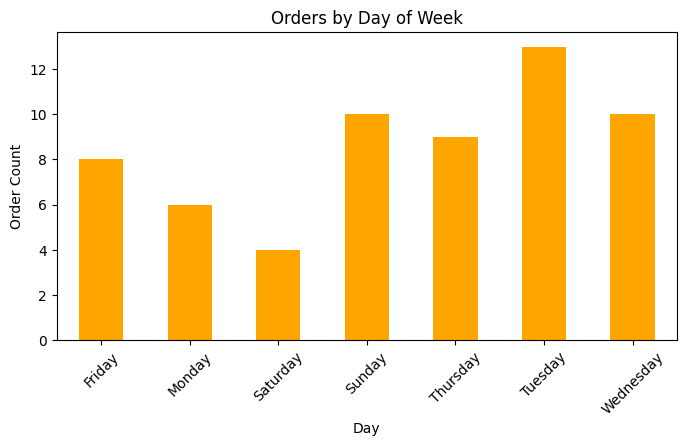

In [22]:
#Peak Sale Days
df['Day'] = df['Date'].dt.day_name()
day_orders = df['Day'].value_counts().sort_index()

plt.figure(figsize=(8,4))
day_orders.plot(kind='bar', color='orange')
plt.title("Orders by Day of Week")
plt.ylabel("Order Count")
plt.xticks(rotation=45)
plt.show()

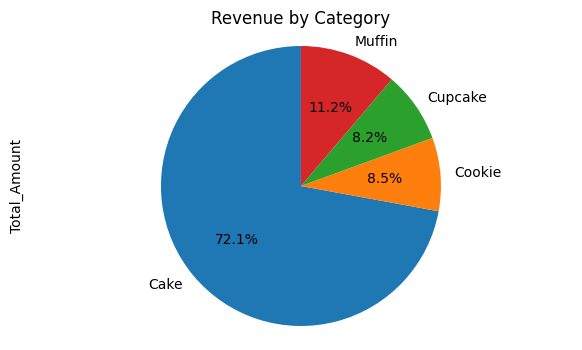

In [23]:
#Revenue by Product Category
category_sales = df.groupby('Category')['Total_Amount'].sum()

plt.figure(figsize=(7,4))
plt.title("Revenue by Category")
category_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.show()

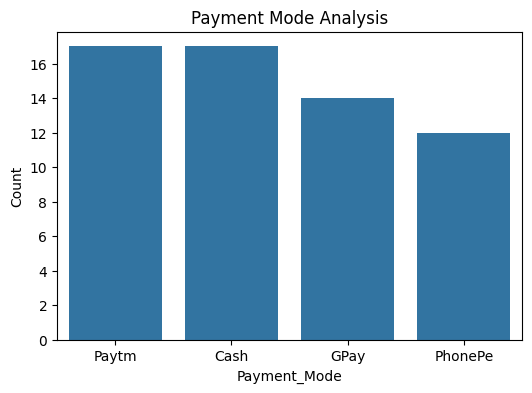

In [24]:
#Payment Mode Analysis
payment_mode = df["Payment_Mode"].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=payment_mode.index, y=payment_mode.values)
plt.title("Payment Mode Analysis")
plt.ylabel('Count')
plt.show()

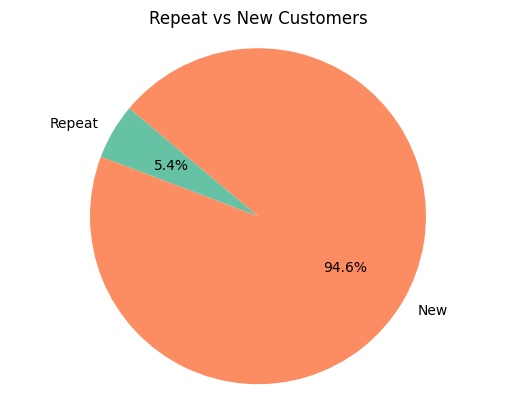

In [25]:
#Repeat vs New Customers
customer_counts = df["Customer_Name"].value_counts()
repeat_customers = customer_counts[customer_counts > 1].count()
new_customers = customer_counts[customer_counts == 1].count()

labels = ["Repeat", "New"]
sizes = [repeat_customers, new_customers]

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=["#66c2a5", "#fc8d62"])
plt.title("Repeat vs New Customers")
plt.axis('equal')
plt.show()


In [27]:
df.to_excel("clean_bakery_data.xlsx", index=False)


In [28]:
from google.colab import files
files.download("clean_bakery_data.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
pastel_colors = ["#ffb3c1", "#c1e1ff", "#ffe4e1", "#d8bfd8", "#f9d5ec"]

# Also define data used in charts
top_items = df["Item_Name"].value_counts().head(5)

monthly = df.groupby(df['Date'].dt.to_period('M')).agg({
    "Total_Amount": "sum",
    "Order_ID": "count"
}).rename(columns={"Order_ID": "Total_Orders"})

customer_counts = df["Customer_Name"].value_counts()
repeat = customer_counts[customer_counts > 1].count()
new = customer_counts[customer_counts == 1].count()


In [33]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns

with PdfPages("bakery_insights.pdf") as pdf:
    # Chart 1
    fig1, ax1 = plt.subplots()
    sns.barplot(x=top_items.index, y=top_items.values, ax=ax1, palette=pastel_colors)
    ax1.set_title("Top 5 Selling Items")
    pdf.savefig(fig1)
    plt.close()

    # Chart 2
    fig2, ax2 = plt.subplots()
    monthly["Total_Amount"].plot(kind="bar", ax=ax2, color="#fc9ab4")
    ax2.set_title("Monthly Revenue")
    pdf.savefig(fig2)
    plt.close()

    # Chart 3: Customer Loyalty
    fig3, ax3 = plt.subplots()
    ax3.pie([repeat, new], labels=["Repeat", "New"], autopct="%1.1f%%", colors=["#66c2a5", "#fc8d62"])
    ax3.set_title("Customer Loyalty")
    pdf.savefig(fig3)
    plt.close()

print("✅ PDF report saved!")


/tmp/ipython-input-33-3025096817.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.index, y=top_items.values, ax=ax1, palette=pastel_colors)


✅ PDF report saved!


In [34]:
from google.colab import files
files.download("bakery_insights.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>